In [2]:
import torch
assert torch.cuda.is_available(), "GPU required"
print(f"GPU: {torch.cuda.get_device_name(0)}")

!pip install -q "rouge-score" "wordcloud" "transformers"

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import T5Tokenizer, T5ForConditionalGeneration
from rouge_score import rouge_scorer
from wordcloud import WordCloud
import warnings; warnings.filterwarnings("ignore")

RANDOM_STATE        = 42
MODEL_NAME          = "t5-base"
N_BATCHES           = 5
N_SAMPLES_PER_BATCH = 15
MAX_INPUT_LEN       = 512
NUM_BEAMS           = 4
MIN_WORDS_TO_SUMMARIZE = 40

device = torch.device("cuda")
np.random.seed(RANDOM_STATE)

CLUSTER_LABELS = {
    0: "Credit Report Disputes",
    1: "Debt Collection & Recovery",
    2: "Card Payments & Account Calls",
}
print("Setup complete")

GPU: Tesla T4
Setup complete


In [3]:
from google.colab import drive
drive.mount("/content/drive")

DATA_PATH = "/content/drive/MyDrive/cfpb_pipeline/data/processed/clustered_data.csv"
FIG_DIR   = "/content/drive/MyDrive/cfpb_pipeline/outputs/figures"
SUM_DIR   = "/content/drive/MyDrive/cfpb_pipeline/outputs/summaries"
for d in [FIG_DIR, SUM_DIR]:
    os.makedirs(d, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

print(f"{'Cluster':<6} {'Label':<35} {'Count':>7} {'%':>6}")
for c in sorted(df["cluster"].unique()):
    n = (df["cluster"] == c).sum()
    print(f"  {c:<4} {CLUSTER_LABELS[c]:<35} {n:>7,} {n/len(df)*100:>5.1f}%")

Mounted at /content/drive
Loaded: 19,997 rows x 14 columns
Cluster Label                                 Count      %
  0    Credit Report Disputes                8,672  43.4%
  1    Debt Collection & Recovery            3,668  18.3%
  2    Card Payments & Account Calls         7,657  38.3%


In [4]:
tokenizer_t5 = T5Tokenizer.from_pretrained(MODEL_NAME)
model_t5     = T5ForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)
model_t5.eval()
print(f"{MODEL_NAME} loaded | params: {sum(p.numel() for p in model_t5.parameters()):,}")

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

t5-base loaded | params: 222,903,552


In [5]:
def create_cluster_input(df, cluster_id, n_samples, random_state):
    pool = df[df["cluster"] == cluster_id]
    pool = pool[pool["text_clean"].str.split().str.len() >= MIN_WORDS_TO_SUMMARIZE]
    sample  = pool.sample(n=min(n_samples, len(pool)), random_state=random_state)
    combined = " ".join(sample["text_clean"].tolist())
    return "summarize: " + combined


def summarize_text(text):
    inputs = tokenizer_t5(
        text,
        return_tensors="pt",
        max_length=MAX_INPUT_LEN,
        truncation=True,
    ).to(device)

    input_len = inputs["input_ids"].shape[1]
    max_sum   = min(150, max(30, input_len // 3))
    min_sum   = min(30,  max(10, input_len // 6))

    with torch.no_grad():
        ids = model_t5.generate(
            inputs.input_ids,
            max_length=max_sum,
            min_length=min_sum,
            num_beams=NUM_BEAMS,
            length_penalty=1.0,
            no_repeat_ngram_size=3,
            early_stopping=True,
        )
    return tokenizer_t5.decode(ids[0], skip_special_tokens=True)


def summarize_cluster(df, cluster_id, n_batches, n_samples):
    return [
        summarize_text(create_cluster_input(df, cluster_id, n_samples, RANDOM_STATE + i))
        for i in range(n_batches)
    ]

test_input   = create_cluster_input(df, 0, 5, RANDOM_STATE)
test_summary = summarize_text(test_input)
print(f"Unit test - Cluster 0 (5 samples):")
print(f"  Input length: {len(test_input.split())} words")
print(f"  Summary length: {len(test_summary.split())} words")
print(f"  Summary: {test_summary[:200]}")

Unit test - Cluster 0 (5 samples):
  Input length: 461 words
  Summary length: 90 words
  Summary: wilshire commercial capital illegally gave my personal information without my consent to a collections company when they closed my account . i then disputed that on and it was resolved the creditor ha


In [6]:
all_summaries = {}

for c in sorted(CLUSTER_LABELS.keys()):
    t0 = time.time()
    print(f"Cluster {c} - {CLUSTER_LABELS[c]}")
    summaries = summarize_cluster(df, c, N_BATCHES, N_SAMPLES_PER_BATCH)
    elapsed = time.time() - t0
    all_summaries[c] = summaries

    print(f"  Generated {len(summaries)} summaries in {elapsed:.1f}s")
    lengths = [len(s.split()) for s in summaries]
    best_idx = np.argmax(lengths)
    print(f"  Word counts: {lengths} | selecting batch {best_idx} (longest)")
    print(f"  Best summary: {summaries[best_idx]}")

print("All summaries generated")

Cluster 0 - Credit Report Disputes
  Generated 5 summaries in 21.0s
  Word counts: [90, 68, 83, 62, 92] | selecting batch 4 (longest)
  Best summary: i have a goal of getting a house as soon as possible but the stuff on my credit report will really put me in trouble this is please do not refute my complaint by stating that i filed this by some other means than myself . i never gave any written consent to report anything on my consumer reports i requiring a proper reinvestigation of disputed items and e b which mandates maximum possible accuracy . the credit bureaus have to modify or delete accounts that are not reporting accurately according to
Cluster 1 - Debt Collection & Recovery
  Generated 5 summaries in 12.6s
  Word counts: [94, 87, 90, 101, 50] | selecting batch 3 (longest)
  Best summary: i was contacted by portfolio recovery associates on multiple occasions i did receive a letter stating that i will be sued for the debt that was sold to them in the original debt was from . i h

 cluster                         label  rouge1_mean  rouge2_mean  rougeL_mean  n_pairs
       0        Credit Report Disputes     0.349188     0.052595     0.177506       10
       1    Debt Collection & Recovery     0.345299     0.054914     0.168011       10
       2 Card Payments & Account Calls     0.219096     0.004556     0.112699       10


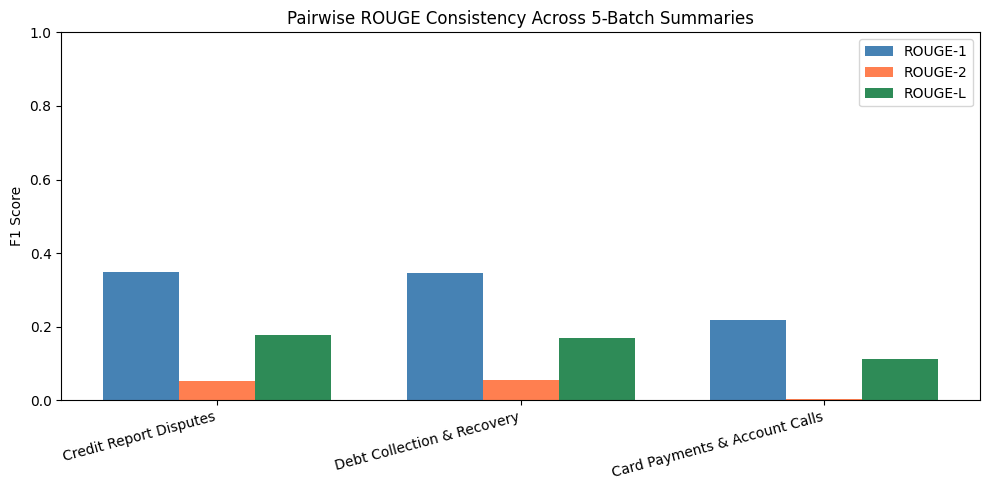

In [7]:
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
rouge_results = []

for c in sorted(CLUSTER_LABELS.keys()):
    summaries = all_summaries[c]
    r1_scores, r2_scores, rl_scores = [], [], []

    for i in range(len(summaries)):
        for j in range(i + 1, len(summaries)):
            scores = scorer.score(summaries[i], summaries[j])
            r1_scores.append(scores["rouge1"].fmeasure)
            r2_scores.append(scores["rouge2"].fmeasure)
            rl_scores.append(scores["rougeL"].fmeasure)

    rouge_results.append({
        "cluster":     c,
        "label":       CLUSTER_LABELS[c],
        "rouge1_mean": np.mean(r1_scores),
        "rouge2_mean": np.mean(r2_scores),
        "rougeL_mean": np.mean(rl_scores),
        "n_pairs":     len(r1_scores),
    })

rouge_df = pd.DataFrame(rouge_results)
print(rouge_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(rouge_df))
width = 0.25
ax.bar(x - width, rouge_df["rouge1_mean"], width, label="ROUGE-1", color="steelblue")
ax.bar(x,         rouge_df["rouge2_mean"], width, label="ROUGE-2", color="coral")
ax.bar(x + width, rouge_df["rougeL_mean"], width, label="ROUGE-L", color="seagreen")
ax.set_xticks(x)
ax.set_xticklabels([CLUSTER_LABELS[c] for c in rouge_df["cluster"]], rotation=15, ha="right")
ax.set(ylabel="F1 Score", title="Pairwise ROUGE Consistency Across 5-Batch Summaries")
ax.legend(); ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_rouge_scores.png", dpi=150, bbox_inches="tight")
plt.show()

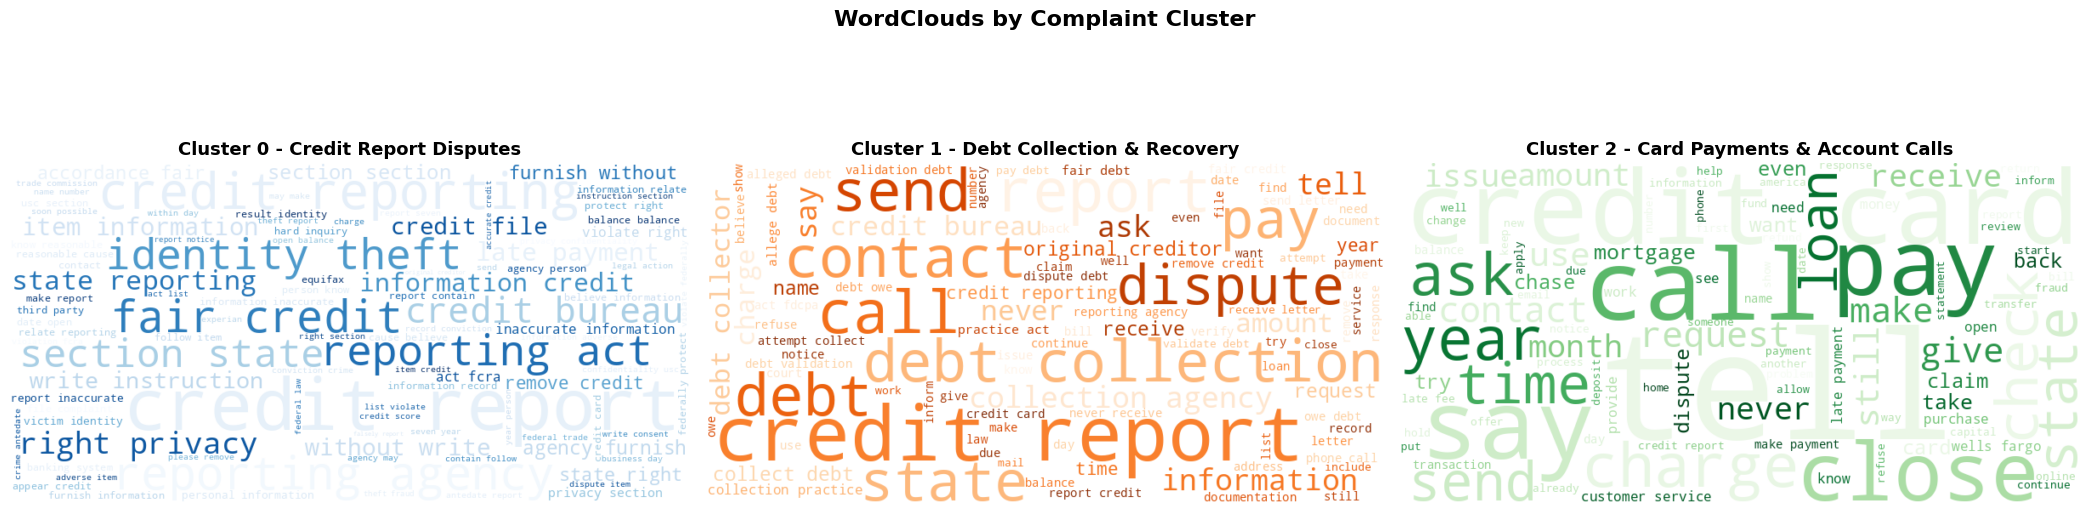

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
colormap_list = ["Blues", "Oranges", "Greens"]

for idx, c in enumerate(sorted(CLUSTER_LABELS.keys())):
    text = " ".join(df.loc[df["cluster"] == c, "text_processed"].dropna().tolist())
    wc = WordCloud(width=800, height=400, max_words=100,
                   background_color="white", colormap=colormap_list[idx],
                   random_state=RANDOM_STATE).generate(text)
    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].set_title(f"Cluster {c} - {CLUSTER_LABELS[c]}", fontsize=13, fontweight="bold")
    axes[idx].axis("off")

plt.suptitle("WordClouds by Complaint Cluster", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
best_summaries = []

for c in sorted(CLUSTER_LABELS.keys()):
    summaries = all_summaries[c]
    lengths   = [len(s.split()) for s in summaries]
    best_idx  = int(np.argmax(lengths))
    best_summaries.append({
        "cluster":            c,
        "label":              CLUSTER_LABELS[c],
        "summary":            summaries[best_idx],
        "word_count":         lengths[best_idx],
        "batch_idx":          best_idx,
        "rouge1_consistency": rouge_df.loc[rouge_df["cluster"] == c, "rouge1_mean"].values[0],
    })

summary_df = pd.DataFrame(best_summaries)
summary_path = f"{SUM_DIR}/cluster_summaries.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Saved: {summary_path}")

Saved: /content/drive/MyDrive/cfpb_pipeline/outputs/summaries/cluster_summaries.csv
